In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.


In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

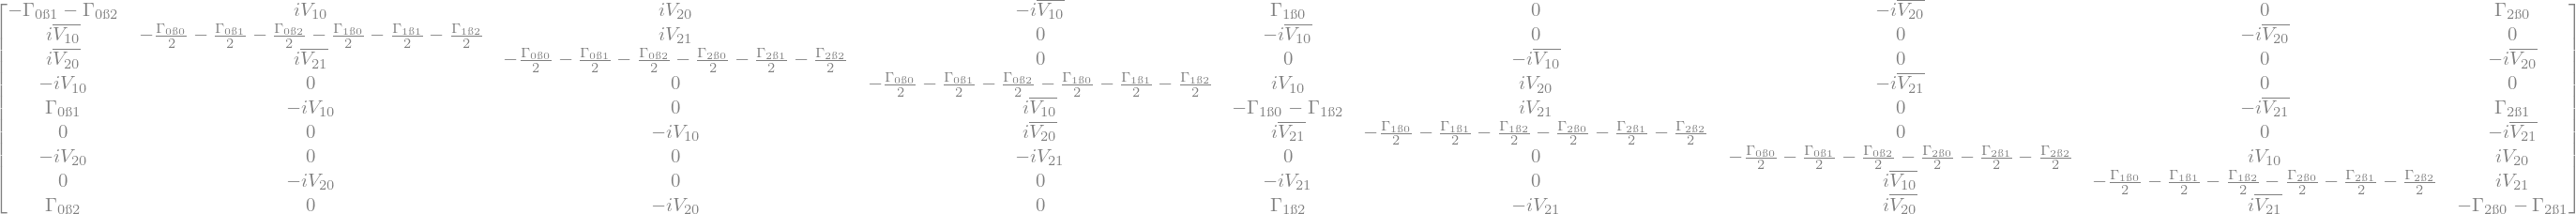

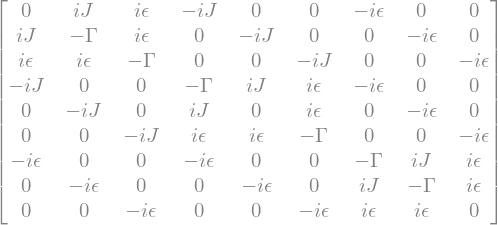

In [3]:
def create_L(output=False):
    # generate general lindbladian
    L, rho = lindbladian(3, output=False, degenerate=True)
    if output: display(L)
    
    # substitute given values
    L = L.subs(sp.Symbol("V10"), J) # strong coupling
    L = L.subs({sp.Symbol("V20"): epsilon, sp.Symbol("V21"): epsilon}) # weak coupling

    L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(3)}) # de phasing

    # no population transitions
    L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(10) for j in range(10)})

    return L, rho


L, rho = create_L(1)

L

In [4]:
L, rho = create_L()

# finding eigenvalues symbolically and storing them in evals list
evals_dict = L.eigenvals()
evals = [key.simplify() for key, val in evals_dict.items()]

for i in evals:
    display(i)

KeyboardInterrupt: 

In [5]:
# subbing in particlar values for J and epsilon
evals_num = []
for val in evals:
    evals_num.append(val.subs({J:0.1, epsilon:1e-4}))

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 30))


for i, ax in enumerate(axes.flat):
    plot_spectrum(evals_num[i], 'Gamma', 1e-6, 1e-1, 1e-4, title=f"eval {i+1}", size=40, color="viridis", norm="log", ax=ax, fig=fig, label=r"$\Gamma$")
    
 
    

# Expanded eigenvals to $O(\epsilon^3)$ assuming that $\epsilon<<1$...

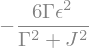

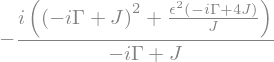

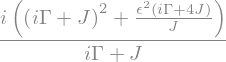

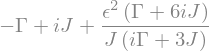

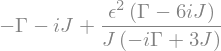

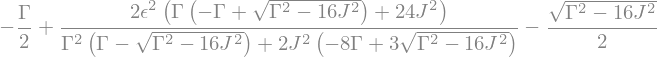

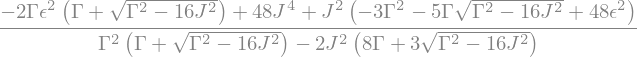

In [5]:
evals_approx = [
    

    -gamma,

    -(6*gamma*epsilon**2)/(gamma**2 + J**2),

    -sp.I * (
        epsilon**2 * (4*J - sp.I*gamma)/J + (J - sp.I*gamma)**2
    ) / (J - sp.I*gamma),

    sp.I * (
        epsilon**2 * (4*J + sp.I*gamma)/J + (J + sp.I*gamma)**2
    ) / (J + sp.I*gamma),

        
     -gamma
    + epsilon**2 * (gamma + 6*sp.I*J) / (J*(3*J + sp.I*gamma))
    + sp.I*J,    
    
    
     -gamma
    + epsilon**2 * (gamma - 6*sp.I*J) / (J*(3*J - sp.I*gamma))
    - sp.I*J,       
              
    



    sp.Rational(1, 2) * (
        -gamma
        + (
            4*epsilon**2 * (
                gamma * (sp.sqrt(gamma**2 - 16*J**2) - gamma)
                + 24*J**2
            )
        ) / (
            2*J**2 * (3*sp.sqrt(gamma**2 - 16*J**2) - 8*gamma)
            + gamma**2 * (gamma - sp.sqrt(gamma**2 - 16*J**2))
        )
        - sp.sqrt(gamma**2 - 16*J**2)
    ),

    (
        48*J**4
        + J**2 * (
            -3*gamma**2
            - 5*gamma*sp.sqrt(gamma**2 - 16*J**2)
            + 48*epsilon**2
        )
        - 2*gamma*epsilon**2 * (
            gamma + sp.sqrt(gamma**2 - 16*J**2)
        )
    ) / (
        gamma**2 * (
            gamma + sp.sqrt(gamma**2 - 16*J**2)
        )
        - 2*J**2 * (
            8*gamma + 3*sp.sqrt(gamma**2 - 16*J**2)
        )
    ),
    
    
    0*gamma,

]

#for i in range(len(evals_approx)):
#    if i not in [1,2,3]: evals_approx[i] = evals_approx[i].subs(epsilon**2, 0)

'''
for i in evals_approx:
    display(sp.re(i)+sp.I*(sp.im(i)))
 '''   

for i in evals_approx:
    display(i)

# small gamma limit upto $O(\Gamma^3)$

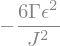

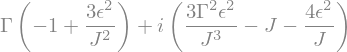

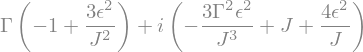

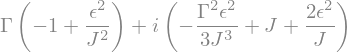

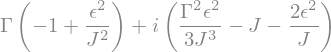

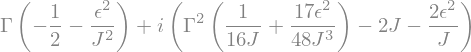

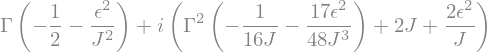

In [8]:
# small gamma limit - second order
for i in evals_approx:
    i = i.series(gamma, 0, 3).removeO()
    display(sp.Add((sp.re(i)),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))

# big gamma limit upto $O(\eta^3)$ with $\eta=1/\Gamma$

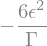

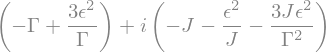

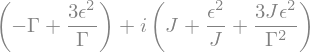

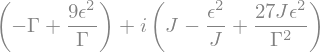

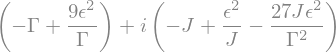

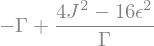

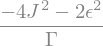

In [9]:
# big gamma limit - second order in eta=1/gamma
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 3).subs(sp.Symbol('eta'), 1/gamma).removeO()
    display(sp.Add((sp.re(i)),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))
    

# eigenvectors expanded to $O(\epsilon^3)$, no restriction on $\Gamma$

In [26]:
a = [[1, 0, 0, 0, 1, 0, 0, 0, 1], [0, J/epsilon, 1, J/epsilon, 0, 1, 1, 1, 0], [-1/2, (3*epsilon**2)/(J**2 + gamma**2), (-3*epsilon)/(2*(J - sp.I*gamma)), (3*epsilon**2)/(J**2 + gamma**2), -1/2, (-3*epsilon)/(2*(J - sp.I*gamma)), 
  (-3*epsilon)/(2*(J + sp.I*gamma)), (-3*epsilon)/(2*(J + sp.I*gamma)), 1], [-1/2, (-(J**2*(J - sp.I*gamma)) + (((-4*sp.I)*J - gamma)*gamma*epsilon**2)/(J - sp.I*gamma))/(2*J**3), 
  (J - sp.I*gamma)/(2*epsilon) + ((4*J**2 + (3*sp.I)*J*gamma + gamma**2)*epsilon)/(4*J**2*(J - sp.I*gamma)), (-(J**2*(J - sp.I*gamma)**2) + ((-4*sp.I)*J - gamma)*gamma*epsilon**2)/(2*J**3*(J - sp.I*gamma)), -1/2, 
  (J - sp.I*gamma)/(2*epsilon) + ((4*J**2 + (3*sp.I)*J*gamma + gamma**2)*epsilon)/(4*J**2*(J - sp.I*gamma)), ((-4*J + sp.I*gamma)*epsilon)/(4*J**2), ((-4*J + sp.I*gamma)*epsilon)/(4*J**2), 1], 
 [-1/2, (-(J**2*(J + sp.I*gamma)) + (((4*sp.I)*J - gamma)*gamma*epsilon**2)/(J + sp.I*gamma))/(2*J**3), -1/4*((4*J + sp.I*gamma)*epsilon)/J**2, (-(J**2*(J + sp.I*gamma)**2) + ((4*sp.I)*J - gamma)*gamma*epsilon**2)/(2*J**3*(J + sp.I*gamma)), 
  -1/2, -1/4*((4*J + sp.I*gamma)*epsilon)/J**2, (J + sp.I*gamma)/(2*epsilon) + ((4*J**2 - (3*sp.I)*J*gamma + gamma**2)*epsilon)/(4*J**2*(J + sp.I*gamma)), 
  (J + sp.I*gamma)/(2*epsilon) + ((4*J**2 - (3*sp.I)*J*gamma + gamma**2)*epsilon)/(4*J**2*(J + sp.I*gamma)), 1], [(3*epsilon)/(3*J + sp.I*gamma), ((-3*J + sp.I*gamma)*epsilon)/(J*(3*J + sp.I*gamma)), 
  -1/2*(gamma*epsilon**2)/(J**2*((-3*sp.I)*J + gamma)), (3*J*epsilon - sp.I*gamma*epsilon)/(3*J**2 + sp.I*J*gamma), (-3*epsilon)/(3*J + sp.I*gamma), (gamma*epsilon**2)/(2*J**2*((-3*sp.I)*J + gamma)), -1, 1, 0], 
 [(3*((2*sp.I)*J**2 + ((12*J + sp.I*gamma)*epsilon**2)/((3*sp.I)*J + gamma)))/(gamma*epsilon), -((2*J**2*(9*J**2 + gamma**2) + (-36*J**2 - (9*sp.I)*J*gamma + gamma**2)*epsilon**2)/(J*gamma*((3*sp.I)*J + gamma)*epsilon)), 
  -2 + ((30*sp.I)*J)/((3*sp.I)*J + gamma) - (2*J**2*((3*sp.I)*J + gamma))/(gamma*epsilon**2) + ((1296*J**4 + (864*sp.I)*J**3*gamma - 279*J**2*gamma**2 - (60*sp.I)*J*gamma**3 + gamma**4)*epsilon**2)/(2*J**2*gamma*((3*sp.I)*J + gamma)**3), 
  (2*J**2*(9*J**2 + gamma**2) + (-36*J**2 - (9*sp.I)*J*gamma + gamma**2)*epsilon**2)/(J*gamma*((3*sp.I)*J + gamma)*epsilon), (3*((-2*sp.I)*J**2 + (((-12*sp.I)*J + gamma)*epsilon**2)/(-3*J + sp.I*gamma)))/(gamma*epsilon), 
  2 - ((30*sp.I)*J)/((3*sp.I)*J + gamma) + (2*J**2*((3*sp.I)*J + gamma))/(gamma*epsilon**2) + (((-1296*sp.I)*J**4 + 864*J**3*gamma + (279*sp.I)*J**2*gamma**2 - 60*J*gamma**3 - sp.I*gamma**4)*epsilon**2)/(2*J**2*(3*J - sp.I*gamma)**3*gamma), 
  -1, 1, 0], [((-2*sp.I)*(6*J**2 + gamma*(-gamma + sp.sqrt(-16*J**2 + gamma**2))))/(((12*sp.I)*J - gamma + 3*sp.sqrt(-16*J**2 + gamma**2))*epsilon) + 
   (((864*sp.I)*J**4 + (2*sp.I)*gamma**3*sp.sqrt(-16*J**2 + gamma**2) - 216*J**3*(2*gamma + sp.sqrt(-16*J**2 + gamma**2)) - (18*sp.I)*J**2*gamma*(3*gamma + 4*sp.sqrt(-16*J**2 + gamma**2)) + 
      3*J*gamma**2*(9*gamma + 7*sp.sqrt(-16*J**2 + gamma**2)))*epsilon)/(144*J**4*gamma + 7*J**2*gamma**3 - gamma**5), 
  (((60*sp.I)*J**2)/gamma + (6*(396*J**3 - (15*sp.I)*gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2)) + (30*sp.I)*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)) - J*gamma*(31*gamma + 45*sp.sqrt(-16*J**2 + gamma**2)))*epsilon**2)/
     (sp.sqrt(-16*J**2 + gamma**2)*(9*J**2*gamma + gamma**3)) + J*(5 - (3*(-80*J**2 + 5*gamma**2 + 8*epsilon**2))/(gamma*sp.sqrt(-16*J**2 + gamma**2))))/(10*epsilon), 
  (4*gamma*(144*J**4 + 4*gamma**3*(gamma - sp.sqrt(-16*J**2 + gamma**2)) + J**2*gamma*(-73*gamma + 39*sp.sqrt(-16*J**2 + gamma**2)) - (36*sp.I)*J*(gamma + sp.sqrt(-16*J**2 + gamma**2))*epsilon**2))/
   (((-12*sp.I)*J + gamma - 3*sp.sqrt(-16*J**2 + gamma**2))**2*(gamma**2*(gamma - sp.sqrt(-16*J**2 + gamma**2)) + 2*J**2*(-8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))), 
  (((-60*sp.I)*J**2)/gamma + (6*(-396*J**3 + (15*sp.I)*gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2)) - (30*sp.I)*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)) + J*gamma*(31*gamma + 45*sp.sqrt(-16*J**2 + gamma**2)))*epsilon**2)/
     (sp.sqrt(-16*J**2 + gamma**2)*(9*J**2*gamma + gamma**3)) + J*(-5 + (3*(-80*J**2 + 5*gamma**2 + 8*epsilon**2))/(gamma*sp.sqrt(-16*J**2 + gamma**2))))/(10*epsilon), 
  ((2*sp.I)*(6*J**2 + gamma*(-gamma + sp.sqrt(-16*J**2 + gamma**2))))/(((12*sp.I)*J - gamma + 3*sp.sqrt(-16*J**2 + gamma**2))*epsilon) + 
   (((-864*sp.I)*J**4 - (2*sp.I)*gamma**3*sp.sqrt(-16*J**2 + gamma**2) + 216*J**3*(2*gamma + sp.sqrt(-16*J**2 + gamma**2)) + (18*sp.I)*J**2*gamma*(3*gamma + 4*sp.sqrt(-16*J**2 + gamma**2)) - 
      3*J*gamma**2*(9*gamma + 7*sp.sqrt(-16*J**2 + gamma**2)))*epsilon)/(144*J**4*gamma + 7*J**2*gamma**3 - gamma**5), 
  (4*gamma*(144*J**4 + 4*gamma**3*(gamma - sp.sqrt(-16*J**2 + gamma**2)) + J**2*gamma*(-73*gamma + 39*sp.sqrt(-16*J**2 + gamma**2)) - (36*sp.I)*J*(gamma + sp.sqrt(-16*J**2 + gamma**2))*epsilon**2))/
   (((-12*sp.I)*J + gamma - 3*sp.sqrt(-16*J**2 + gamma**2))**2*(J**2*(16*gamma - 6*sp.sqrt(-16*J**2 + gamma**2)) + gamma**2*(-gamma + sp.sqrt(-16*J**2 + gamma**2)))), -1, 1, 0], 
 [((-2*sp.I)*(-6*J**2 + gamma*(gamma + sp.sqrt(-16*J**2 + gamma**2))))/(((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))*epsilon) + 
   (((864*sp.I)*J**4 - (2*sp.I)*gamma**3*sp.sqrt(-16*J**2 + gamma**2) + 3*J*gamma**2*(9*gamma - 7*sp.sqrt(-16*J**2 + gamma**2)) + 216*J**3*(-2*gamma + sp.sqrt(-16*J**2 + gamma**2)) + 
      (18*sp.I)*J**2*gamma*(-3*gamma + 4*sp.sqrt(-16*J**2 + gamma**2)))*epsilon)/(144*J**4*gamma + 7*J**2*gamma**3 - gamma**5), (J*((12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))/(2*gamma*epsilon) + 
   (24*J*((288*sp.I)*J**3 + 4*gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2)) - 24*J**2*(2*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)) - (3*sp.I)*J*gamma*(5*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))*epsilon)/
    (((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))**2*(-(gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2))) + 2*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))), 
  (4*gamma*(144*J**4 + 4*gamma**3*(gamma + sp.sqrt(-16*J**2 + gamma**2)) - J**2*gamma*(73*gamma + 39*sp.sqrt(-16*J**2 + gamma**2)) + (36*sp.I)*J*(-gamma + sp.sqrt(-16*J**2 + gamma**2))*epsilon**2))/
   (((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))**2*(gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2)) - 2*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))), 
  (J*(-(((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))*(5*gamma + 3*sp.sqrt(-16*J**2 + gamma**2))) + 
     (24*((-288*sp.I)*J**3 - 4*gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2)) + 24*J**2*(2*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)) + (3*sp.I)*J*gamma*(5*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))*epsilon**2)/
      (-(gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2))) + 2*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))))/(((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))**2*epsilon), 
  ((2*sp.I)*(-6*J**2 + gamma*(gamma + sp.sqrt(-16*J**2 + gamma**2))))/(((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))*epsilon) + 
   (((-864*sp.I)*J**4 + (2*sp.I)*gamma**3*sp.sqrt(-16*J**2 + gamma**2) - 216*J**3*(-2*gamma + sp.sqrt(-16*J**2 + gamma**2)) - (18*sp.I)*J**2*gamma*(-3*gamma + 4*sp.sqrt(-16*J**2 + gamma**2)) + 
      3*J*gamma**2*(-9*gamma + 7*sp.sqrt(-16*J**2 + gamma**2)))*epsilon)/(144*J**4*gamma + 7*J**2*gamma**3 - gamma**5), 
  (4*gamma*(144*J**4 + 4*gamma**3*(gamma + sp.sqrt(-16*J**2 + gamma**2)) - J**2*gamma*(73*gamma + 39*sp.sqrt(-16*J**2 + gamma**2)) + (36*sp.I)*J*(-gamma + sp.sqrt(-16*J**2 + gamma**2))*epsilon**2))/
   (((-12*sp.I)*J + gamma + 3*sp.sqrt(-16*J**2 + gamma**2))**2*(-(gamma**2*(gamma + sp.sqrt(-16*J**2 + gamma**2))) + 2*J**2*(8*gamma + 3*sp.sqrt(-16*J**2 + gamma**2)))), -1, 1, 0],
    ]



In [27]:
for i in a:
    display(sp.Matrix(i).applyfunc(lambda n: sp.Symbol('\\ast') if not (n==0) else n).T)

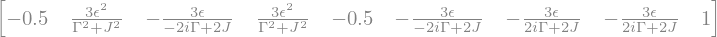

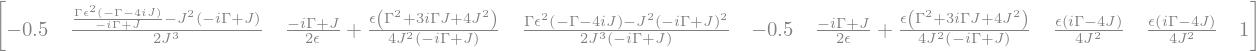

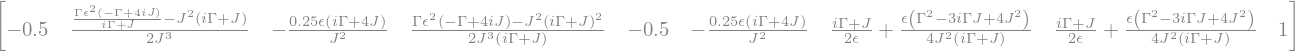

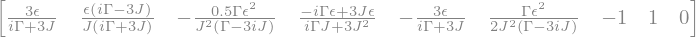

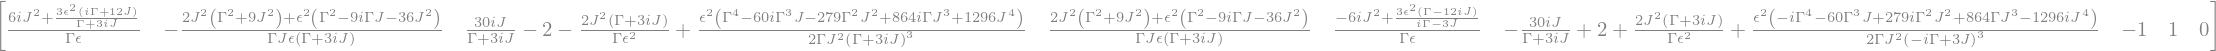

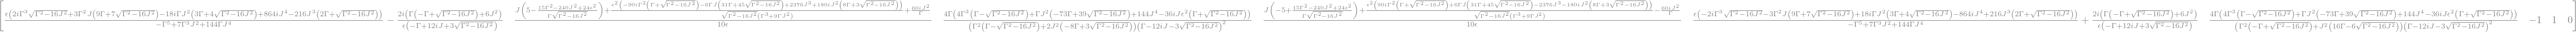

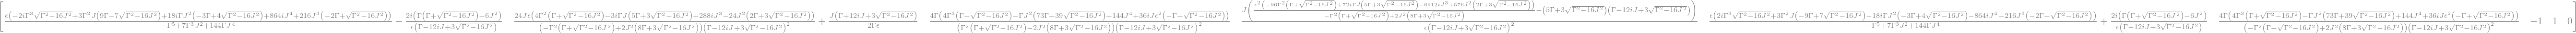

In [24]:
for i in a:
    display(sp.Matrix(i).T)

In [12]:
# subbing in particlar values for J and epsilon
evals_approx_num = []
for val in evals_approx:
    evals_approx_num.append(val.subs({J:0.1, epsilon:1e-4}))


In [13]:
fig, axes = plt.subplots(4, 2, figsize=(20, 34))


for i, ax in enumerate(axes.flat):
    plot_spectrum(evals_num[i], 'Gamma', 1e-6, 1e-2, 1e-4, label=f"exact", size=40, color="viridis", norm="log", ax=ax, fig=fig)
    plot_spectrum(evals_approx_num[i], 'Gamma', 1e-6, 1e-2, 1e-4, label=f"approx", size=5, color="Reds", norm="log", ax=ax, fig=fig)
    
    
    